# VMD-DTW 相似性分析

对预处理后的所有建筑负荷数据进行标准化，然后计算任意两个建筑负荷序列之间的相似度，用于选择迁移学习最佳源域-目标域组合。

## 分析流程

1. **数据标准化**：对所有建筑的特征数据进行标准化（仅在自身维度上）
2. **VMD分解**：将负荷序列分解为多个本征模态函数IMF
3. **DTW距离**：计算各IMF的动态时间规整距离
4. **加权相似度**：低频IMF权重更高，计算综合相似度
5. **迁移方向**：数据量大的建筑作为源域，数据量小的建筑作为目标域

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from vmdpy import VMD
from dtaidistance import dtw
from typing import Tuple, Dict
from itertools import combinations
from concurrent.futures import ThreadPoolExecutor, as_completed
from tabulate import tabulate
import json

# 从 src 模块导入共享配置
from src import (
    BASE_DIR,
    BUILDINGS_DIR,
    BUILDINGS,
    TARGET_COL,
    TARGET_SAMPLE_START,
    TARGET_SAMPLE_END,
    SEED,
    FIGURES_DIR,
)

np.random.seed(SEED)

plt.style.use('default')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 加载并标准化数据

对每个建筑的负荷数据进行标准化（仅在自身维度上），用于相似性分析。

In [2]:
def load_and_standardize_building(building_name: str) -> Tuple[pd.DataFrame, StandardScaler]:
    path = BUILDINGS_DIR / f'{building_name}_特征.csv'
    df = pd.read_csv(path, encoding='utf-8-sig')
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp', TARGET_COL]).sort_values('timestamp').reset_index(drop=True)
    
    # 保存原始负荷数据
    df['original_load'] = df[TARGET_COL].copy()
    
    # 标准化负荷数据（用于VMD分析）
    scaler = StandardScaler()
    df[TARGET_COL] = scaler.fit_transform(df[[TARGET_COL]])
    
    return df, scaler

# 加载所有建筑数据
building_data = {}
for name in BUILDINGS:
    df, scaler = load_and_standardize_building(name)
    building_data[name] = {
        'df': df,
        'scaler': scaler,
    }

## VMD-DTW 分析函数

In [3]:
def determine_optimal_k(signal: np.ndarray, alpha: float = 2000, k_range: range = range(1, 7)) -> int:
    """基于中心频率稳定性，选择中心频率变化最小的 K"""
    center_freq_results = []
    for K_test in k_range:
        _, _, omega_test = VMD(signal, alpha, 0, K_test, 0, 1, 1e-7)
        last_freq = omega_test[-1, -1]
        center_freq_results.append({'K': K_test, 'last_center_freq': last_freq})
    
    freq_df = pd.DataFrame(center_freq_results)
    freq_df['freq_change'] = freq_df['last_center_freq'].diff().abs()
    min_change_idx = freq_df['freq_change'].idxmin()
    return int(freq_df.loc[min_change_idx, 'K'])


def compute_imf_weights(center_freq: np.ndarray, decay_factor: float = 2.0) -> np.ndarray:
    """
    基于中心频率计算各 IMF 层的权重
    
    Args:
        center_freq: 各 IMF 的中心频率数组（按频率从低到高排列）
        decay_factor: 衰减因子，控制权重递减速度
                     - decay_factor=1: 线性递减
                     - decay_factor=2: 平方反比（推荐）
                     - decay_factor>2: 更强调低频
    
    Returns:
        归一化的权重数组
    """
    # 避免除零
    freq_safe = np.maximum(center_freq, 1e-6)
    
    # 基于中心频率的权重：频率越低，权重越大
    # 使用幂函数衰减：weight ∝ 1 / f^decay_factor
    weights = 1.0 / (freq_safe ** (1.0 / decay_factor))
    weights = weights / weights.sum()
    
    return weights


def compute_vmd_dtw_similarity(
    source_signal: np.ndarray,
    target_signal: np.ndarray,
    K: int,
    alpha: float = 2000,
) -> Dict:
    # VMD 分解
    u_source, _, omega_source = VMD(source_signal, alpha, 0, K, 0, 1, 1e-7)
    u_target, _, omega_target = VMD(target_signal, alpha, 0, K, 0, 1, 1e-7)
    
    # 提取中心频率（取源域和目标域的平均值计算权重）
    center_freq_source = omega_source[-1, :K]
    center_freq_target = omega_target[-1, :K]
    center_freq_mean = (center_freq_source + center_freq_target) / 2
    
    # 基于中心频率计算权重
    weights_norm = compute_imf_weights(center_freq_mean)
    
    # 计算各层 DTW 距离
    dtw_distances = []
    for i in range(K):
        dtw_dist = dtw.distance(u_source[i, :], u_target[i, :], use_pruning=True)
        dtw_distances.append(dtw_dist)
    
    # 原始序列 DTW 距离
    dtw_original = dtw.distance(source_signal, target_signal, use_pruning=True)
    
    # 加权 DTW
    weighted_dtw = np.sum(np.array(dtw_distances) * weights_norm)
    
    # 相似度
    max_dtw = max(dtw_original, weighted_dtw)
    similarity = 1 - (weighted_dtw / max_dtw) if max_dtw > 0 else 0
    
    return {
        'K': K,
        'dtw_distances': dtw_distances,
        'dtw_original': dtw_original,
        'weighted_dtw': weighted_dtw,
        'weights': weights_norm,
        'similarity': similarity,
        'u_source': u_source,
        'u_target': u_target,
        'center_freq_source': center_freq_source,
        'center_freq_target': center_freq_target,
    }


def _compute_pair_similarity_task(args: tuple) -> Dict:
    """并行计算单个建筑对的相似度"""
    source_name, target_name, source_signal, target_signal, K = args
    
    result = compute_vmd_dtw_similarity(source_signal, target_signal, K)
    result['source_name'] = source_name
    result['target_name'] = target_name
    
    return result

## 计算所有建筑对的相似度

为提高效率，预先计算每个建筑的最优 VMD 分解层数 K

In [4]:
print(f"分析时间段: {TARGET_SAMPLE_START} ~ {TARGET_SAMPLE_END}")

# 预计算每个建筑的 K 值和数据量
building_k = {}
building_data_count = {}

for name in BUILDINGS:
    df = building_data[name]['df']
    load_series = df.set_index('timestamp')[TARGET_COL].dropna()
    signal = load_series.values.astype(np.float64)
    
    k_value = determine_optimal_k(signal)
    building_k[name] = k_value
    building_data_count[name] = len(signal)

# 准备每对建筑的数据（相似度对称只计算一次）
pair_tasks = []
pair_metadata = []

for building_a, building_b in combinations(BUILDINGS, 2):
    # 获取公共时间段
    df_a = building_data[building_a]['df']
    df_b = building_data[building_b]['df']
    
    load_a = df_a.set_index('timestamp')[TARGET_COL].dropna()
    load_b = df_b.set_index('timestamp')[TARGET_COL].dropna()
    
    common_idx = load_a.index.intersection(load_b.index)
    
    # 筛选分析时间段
    if TARGET_SAMPLE_START and TARGET_SAMPLE_END:
        mask = (common_idx >= TARGET_SAMPLE_START) & (common_idx < TARGET_SAMPLE_END)
        common_idx = common_idx[mask]
    
    # 提取标准化信号（用于VMD分析）
    signal_a = load_a.loc[common_idx].values.astype(np.float64)
    signal_b = load_b.loc[common_idx].values.astype(np.float64)
    
    # 提取原始负荷数据（用于可视化）
    original_load_a = df_a.set_index('timestamp').loc[common_idx, 'original_load']
    original_load_b = df_b.set_index('timestamp').loc[common_idx, 'original_load']
    
    # 使用两个建筑 K 值的较大者（保证对称性）
    K = max(building_k[building_a], building_k[building_b])
    
    # 根据数据量确定源域和目标域（数据量大的作为源域）
    if building_data_count[building_a] >= building_data_count[building_b]:
        source_candidate, target_candidate = building_a, building_b
    else:
        source_candidate, target_candidate = building_b, building_a
    
    # 准备任务参数
    pair_tasks.append((building_a, building_b, signal_a, signal_b, K))
    pair_metadata.append({
        'building_a': building_a,
        'building_b': building_b,
        'common_idx': common_idx,
        'original_load_a': original_load_a,
        'original_load_b': original_load_b,
        'source_candidate': source_candidate,
        'target_candidate': target_candidate,
    })

# 并行计算
all_results = {}
max_workers = min(len(pair_tasks), 5)

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {executor.submit(_compute_pair_similarity_task, task): i 
               for i, task in enumerate(pair_tasks)}
    
    completed = 0
    for future in as_completed(futures):
        idx = futures[future]
        try:
            result = future.result()
            pair_key = f"{result['source_name']}-{result['target_name']}"
            
            meta = pair_metadata[idx]
            result['common_index'] = meta['common_idx']
            result['original_load_a'] = meta['original_load_a']
            result['original_load_b'] = meta['original_load_b']
            result['source_candidate'] = meta['source_candidate']
            result['target_candidate'] = meta['target_candidate']
            
            all_results[pair_key] = result
            
            completed += 1
            print(f"[{completed}/{len(pair_tasks)}] {meta['source_candidate']}->{meta['target_candidate']} 相似度: {result['similarity']:.4f}")
            
        except Exception as e:
            print(f"  任务失败: {e}")

分析时间段: 2024-03-15 ~ 2024-07-01
[1/10] 南阶->西阶 相似度: 0.5338
[2/10] 南阶->粉体 相似度: 0.1585
[3/10] 南阶->土木 相似度: 0.5656
[4/10] 土木->西阶 相似度: 0.4830
[5/10] 粉体->西阶 相似度: 0.0000
[6/10] 南阶->环工 相似度: 0.5053
[7/10] 环工->西阶 相似度: 0.6327
[8/10] 环工->土木 相似度: 0.4655
[9/10] 土木->粉体 相似度: 0.3785
[10/10] 环工->粉体 相似度: 0.5418


## 相似度汇总与最佳组合选择

In [5]:
# 汇总相似度数据
summary_data = []
for pair_name, result in all_results.items():
    summary_data.append({
        '建筑对': pair_name,
        '源域': result['source_candidate'],
        '目标域': result['target_candidate'],
        'K': result['K'],
        '加权DTW': round(result['weighted_dtw'], 4),
        '原始DTW': round(result['dtw_original'], 4),
        '相似度': round(result['similarity'], 4),
    })
summary_df = pd.DataFrame(summary_data).sort_values('相似度', ascending=False)
print(tabulate(summary_df, headers='keys', tablefmt='grid', showindex=False))

# 最佳组合
best_pair = summary_df.iloc[0]
print(f"\n推荐: {best_pair['源域']} → {best_pair['目标域']} (相似度 {best_pair['相似度']:.4f})")

# 保存 JSON
json_results = {}
for pair_key, result in all_results.items():
    K = result['K']
    json_results[pair_key] = {
        'source': result['source_candidate'],
        'target': result['target_candidate'],
        'K': int(result['K']),
        'similarity': round(float(result['similarity']), 6),
        'weighted_dtw': round(float(result['weighted_dtw']), 4),
        'dtw_original': round(float(result['dtw_original']), 4),
        'center_freq_source': [round(float(f), 6) for f in result['center_freq_source']],
        'center_freq_target': [round(float(f), 6) for f in result['center_freq_target']],
        'dtw_distances': [round(float(d), 4) for d in result['dtw_distances']],
        'weights': [round(float(w), 4) for w in result['weights']],
    }

with open(BASE_DIR / '相似性分析完整结果.json', 'w', encoding='utf-8') as f:
    json.dump(json_results, f, ensure_ascii=False, indent=2)

summary_df.to_csv(BASE_DIR / '相似性分析汇总.csv', index=False, encoding='utf-8-sig')
print(f"\n已保存: 相似性分析完整结果.json, 相似性分析汇总.csv")

+-----------+--------+----------+-----+-----------+-----------+----------+
| 建筑对    | 源域   | 目标域   |   K |   加权DTW |   原始DTW |   相似度 |
+===========+========+==========+=====+===========+===========+==========+
| 西阶-环工 | 环工   | 西阶     |   6 |    7.5078 |   20.4403 |   0.6327 |
+-----------+--------+----------+-----+-----------+-----------+----------+
| 南阶-土木 | 南阶   | 土木     |   5 |   13.1884 |   30.3577 |   0.5656 |
+-----------+--------+----------+-----+-----------+-----------+----------+
| 环工-粉体 | 环工   | 粉体     |   6 |    9.6482 |   21.0559 |   0.5418 |
+-----------+--------+----------+-----+-----------+-----------+----------+
| 南阶-西阶 | 南阶   | 西阶     |   4 |   12.5733 |   26.9683 |   0.5338 |
+-----------+--------+----------+-----+-----------+-----------+----------+
| 南阶-环工 | 南阶   | 环工     |   6 |   12.4799 |   25.2293 |   0.5053 |
+-----------+--------+----------+-----+-----------+-----------+----------+
| 西阶-土木 | 土木   | 西阶     |   5 |    9.4232 |   18.2272 |   0.483  |
+-----------+

## 可视化分析结果

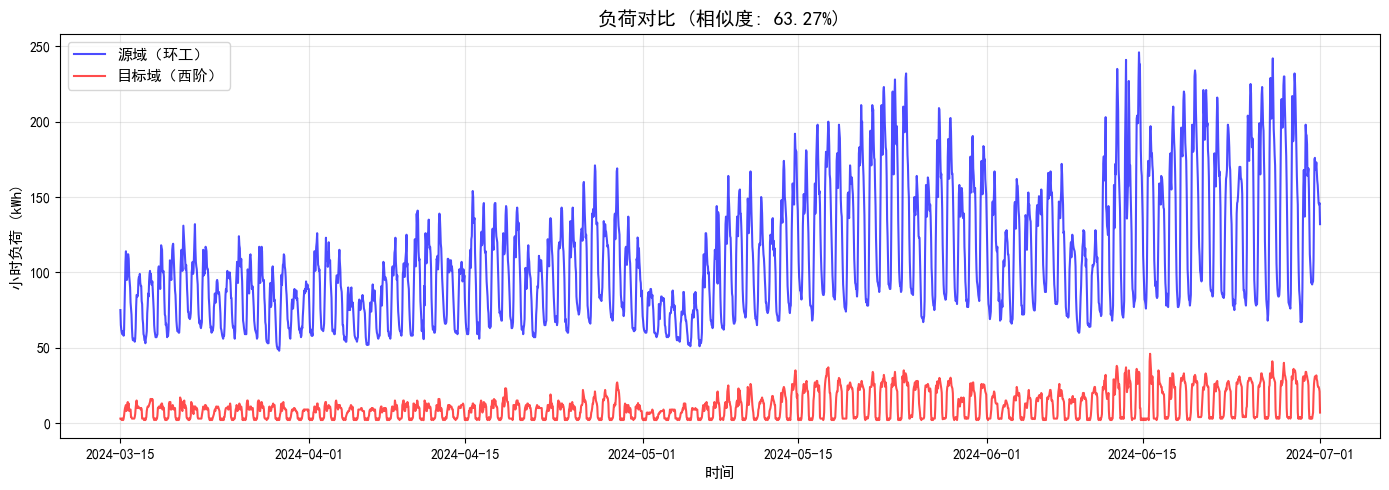

In [6]:
# 选择最佳建筑对进行详细可视化
best_pair_key = best_pair['建筑对']
result = all_results[best_pair_key]
common_idx = result['common_index']
K = result['K']

# 确定源域和目标域
source_name = result['source_candidate']
target_name = result['target_candidate']
source_load = result['original_load_a'] if source_name == result.get('building_a', result['source_name']) else result['original_load_b']
target_load = result['original_load_b'] if target_name == result.get('building_b', result['target_name']) else result['original_load_a']

# 1. 原始负荷对比
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(common_idx, source_load.values, 'b-', alpha=0.7, label=f'源域（{source_name}）')
ax.plot(common_idx, target_load.values, 'r-', alpha=0.7, label=f'目标域（{target_name}）')
ax.set_title(f"负荷对比 (相似度: {result['similarity']*100:.2f}%)", fontsize=14)
ax.set_xlabel('时间', fontsize=11)
ax.set_ylabel('小时负荷 (kWh)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '原始负荷对比.png', dpi=150, bbox_inches='tight')
plt.show()

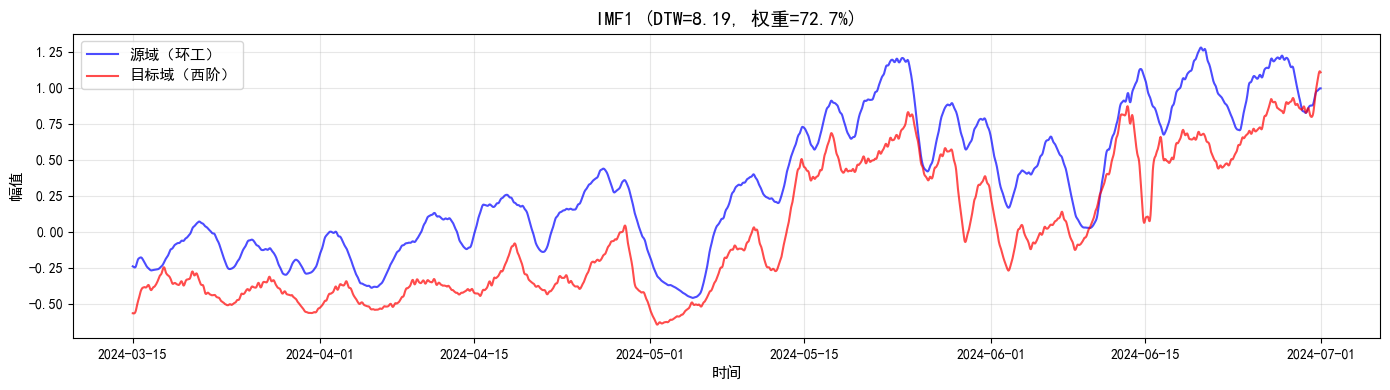

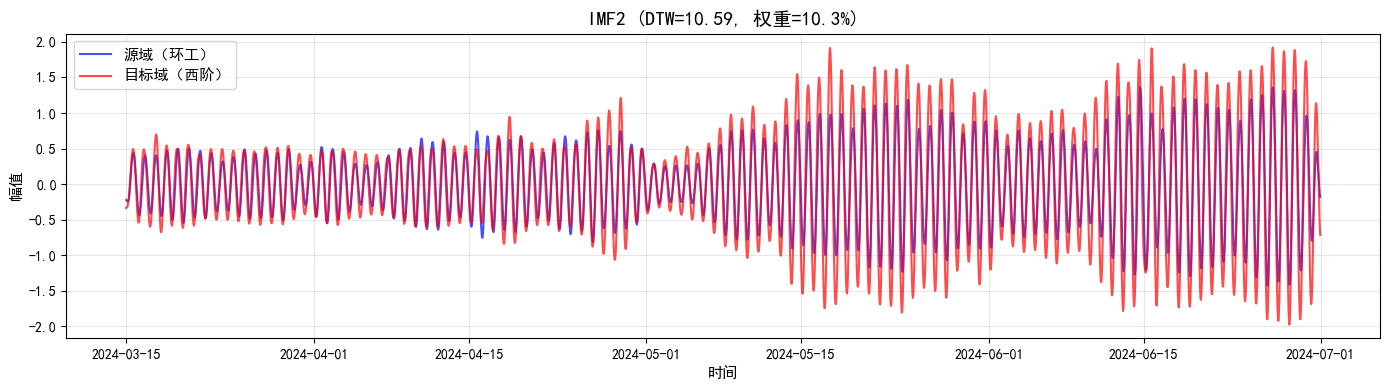

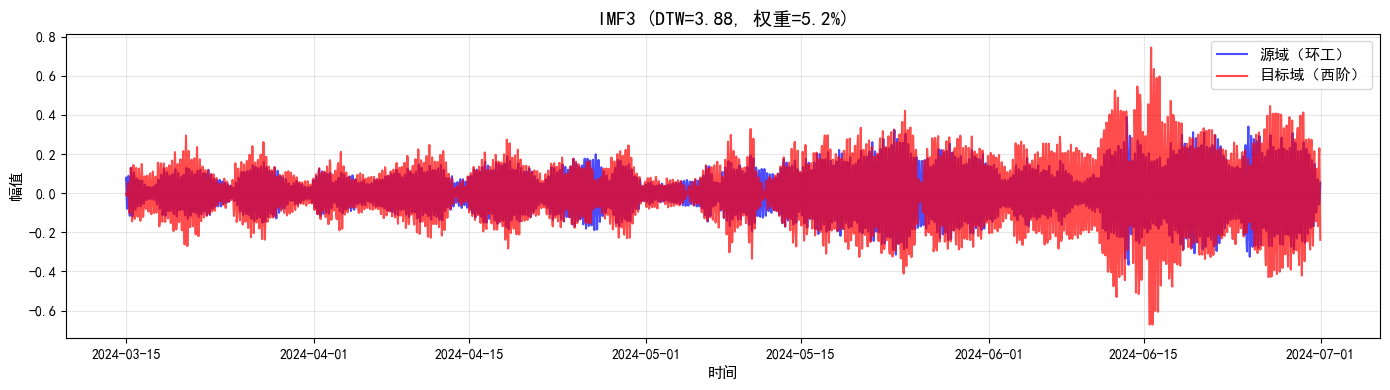

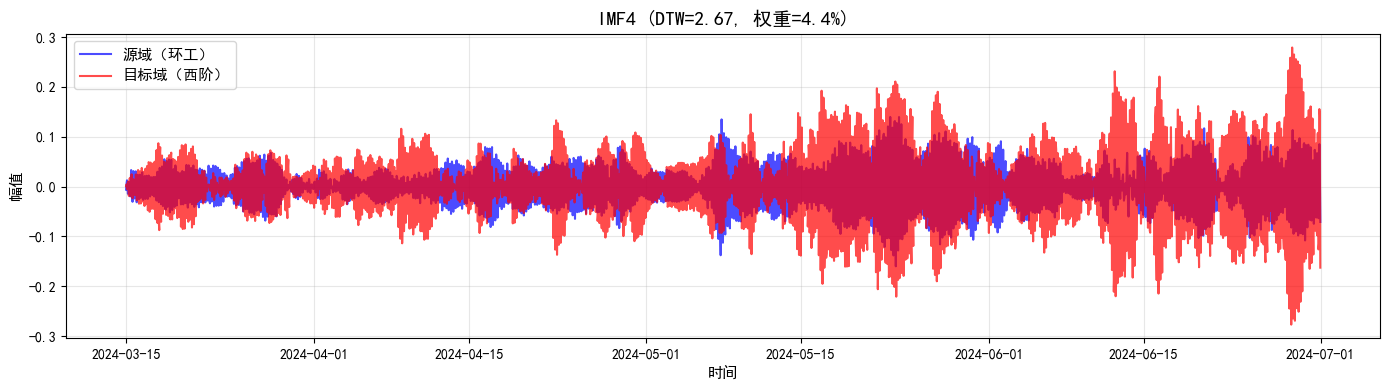

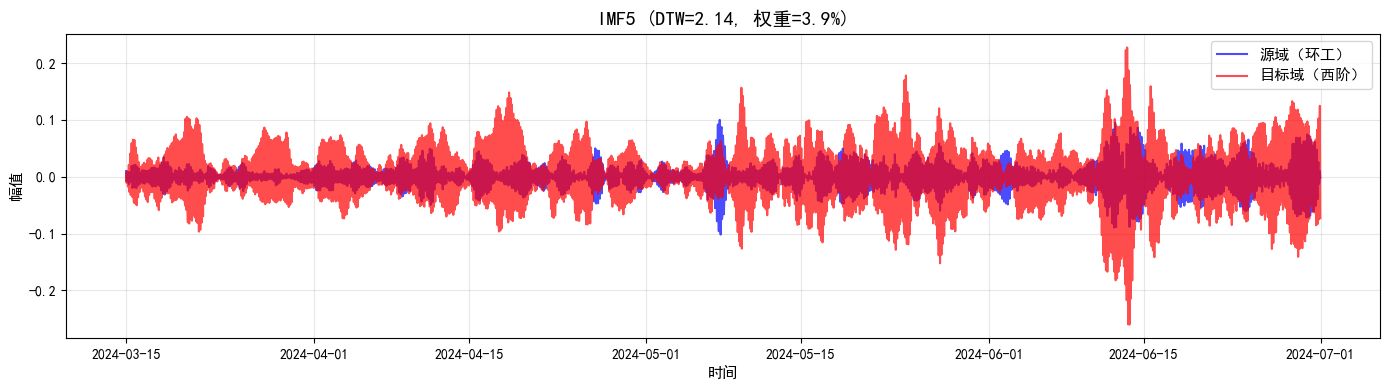

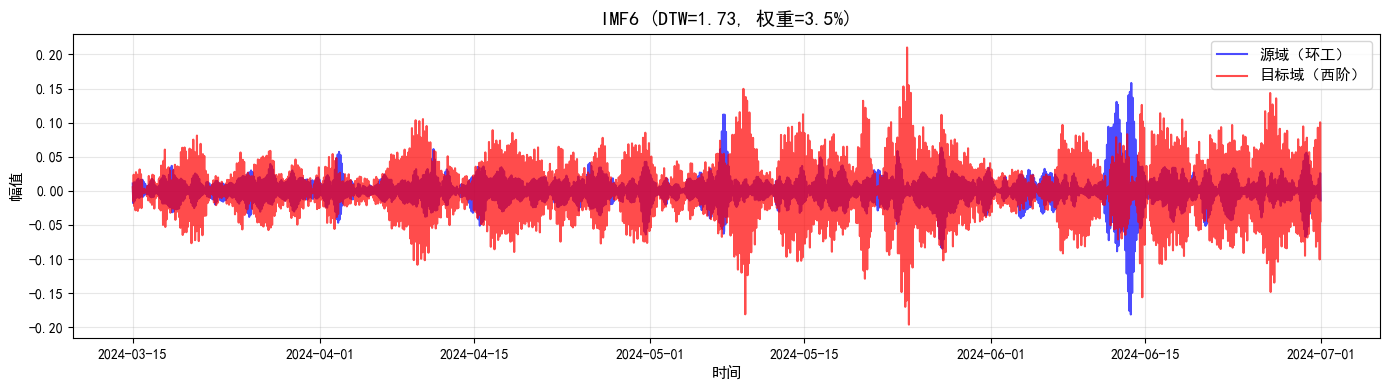

In [7]:
# 2. 各 IMF 分量对比
# 确定哪个索引对应源域和目标域
source_idx = 0 if source_name == result.get('building_a', result['source_name']) else 1
target_idx = 1 - source_idx

u_source = result['u_source'] if source_idx == 0 else result['u_target']
u_target = result['u_target'] if source_idx == 0 else result['u_source']

for i in range(K):
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(common_idx, u_source[i, :], 'b-', alpha=0.7, label=f'源域（{source_name}）')
    ax.plot(common_idx, u_target[i, :], 'r-', alpha=0.7, label=f'目标域（{target_name}）')
    ax.set_title(f"IMF{i+1} (DTW={result['dtw_distances'][i]:.2f}, 权重={result['weights'][i]*100:.1f}%)", fontsize=14)
    ax.set_xlabel('时间', fontsize=11)
    ax.set_ylabel('幅值', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'IMF{i+1}对比.png', dpi=150, bbox_inches='tight')
    plt.show()

选择第 23 周作为典型周


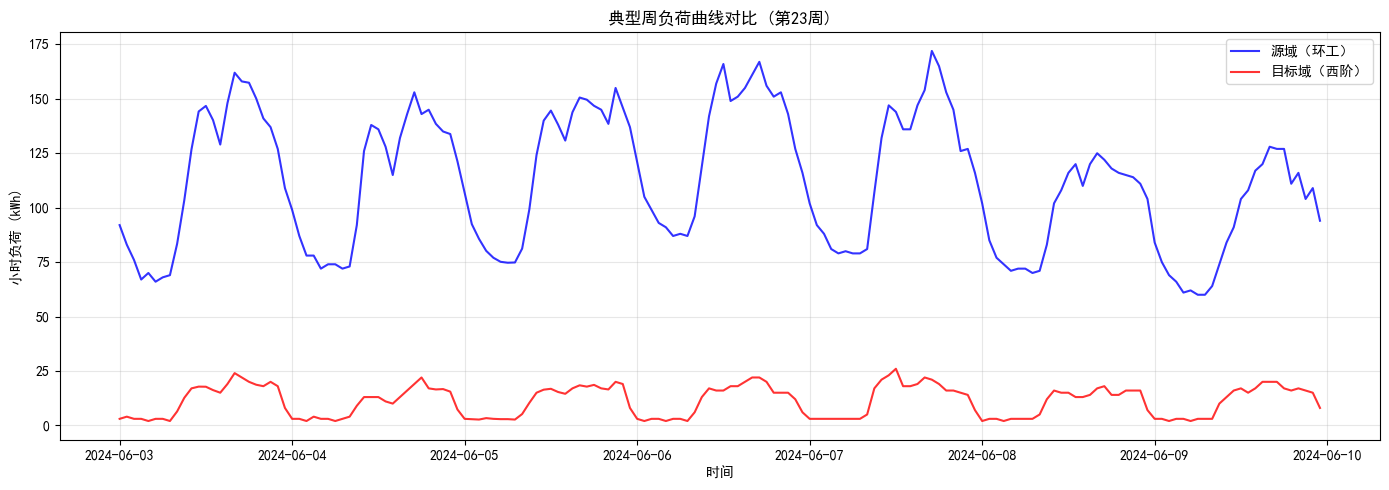

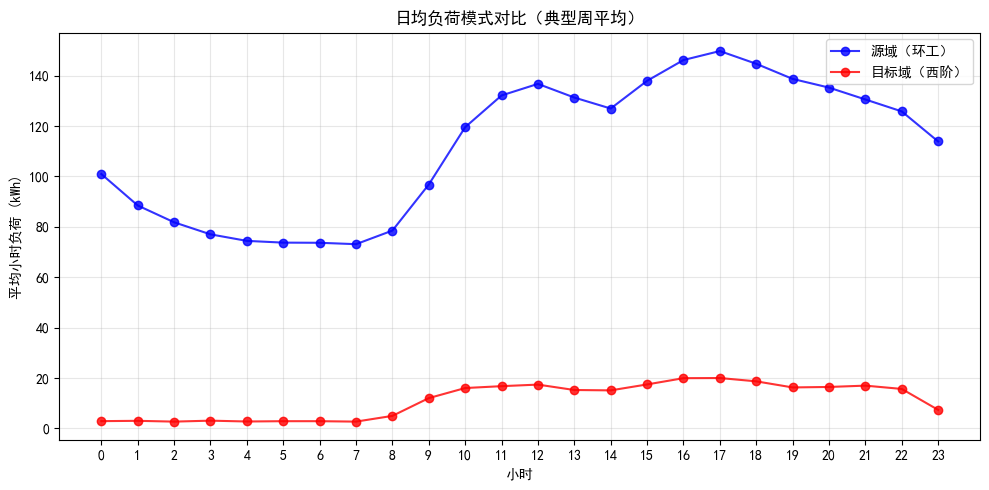

In [8]:
# 按周划分数据
df_weekly = pd.DataFrame({
    'source': source_load.loc[common_idx].values,
    'target': target_load.loc[common_idx].values,
}, index=common_idx)
df_weekly['week'] = df_weekly.index.isocalendar().week

# 选择周均负荷最接近整体均值的周作为典型周
weekly_stats = df_weekly.groupby('week').agg({'source': 'mean', 'target': 'mean'})
overall_mean_source = df_weekly['source'].mean()
overall_mean_target = df_weekly['target'].mean()

weekly_stats['total_diff'] = (
    abs(weekly_stats['source'] - overall_mean_source) +
    abs(weekly_stats['target'] - overall_mean_target)
)
typical_week = weekly_stats['total_diff'].idxmin()

print(f"选择第 {typical_week} 周作为典型周")

# 提取典型周数据
typical_week_idx = common_idx[common_idx.isocalendar().week == typical_week]

if len(typical_week_idx) >= 24:
    source_typical = source_load.loc[typical_week_idx]
    target_typical = target_load.loc[typical_week_idx]
    
    # 图1：典型周负荷曲线
    fig1, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(typical_week_idx, source_typical.values, 'b-', label=f'源域（{source_name}）', alpha=0.8)
    ax1.plot(typical_week_idx, target_typical.values, 'r-', label=f'目标域（{target_name}）', alpha=0.8)
    ax1.set_xlabel('时间')
    ax1.set_ylabel('小时负荷 (kWh)')
    ax1.set_title(f'典型周负荷曲线对比 (第{typical_week}周)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 图2：日均负荷模式
    source_daily = source_typical.groupby(source_typical.index.hour).mean()
    target_daily = target_typical.groupby(target_typical.index.hour).mean()
    
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.plot(range(24), source_daily.values, 'b-o', label=f'源域（{source_name}）', alpha=0.8)
    ax2.plot(range(24), target_daily.values, 'r-o', label=f'目标域（{target_name}）', alpha=0.8)
    ax2.set_xlabel('小时')
    ax2.set_ylabel('平均小时负荷 (kWh)')
    ax2.set_title('日均负荷模式对比（典型周平均）')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(range(24))
    plt.tight_layout()
    plt.show()

## 输出文件说明

**数据文件（`data/`）：**
| 文件 | 说明 |
|------|------|
| `相似性分析完整结果.json` | 完整分析结果（K值、相似度、DTW距离、权重） |
| `相似性分析汇总.csv` | 建筑对汇总表 |

**图表文件（`data/figures/`）：**
| 文件 | 说明 |
|------|------|
| `原始负荷对比.png` | 源域与目标域负荷对比 |
| `IMF1对比.png` ~ `IMF{n}对比.png` | IMF 分量对比 |

### JSON 结构

```json
{
  "建筑A-建筑B": {
    "source": "源域建筑",
    "target": "目标域建筑",
    "K": "VMD分解层数",
    "similarity": "综合相似度",
    "weighted_dtw": "加权DTW距离",
    "dtw_original": "原始序列DTW距离",
    "center_freq_source": ["源域各IMF中心频率"],
    "center_freq_target": ["目标域各IMF中心频率"],
    "dtw_distances": ["各IMF层DTW距离"],
    "weights": ["各IMF层权重"]
  }
}
```